# 04. Exploratory Data Analysis

**Aim:** Generate statistical summaries and perform univariate and multivariate analysis on the PlantDoc dataset.

## Theory

Exploratory Data Analysis (EDA) helps us understand the structure, spread, and relationships inside the dataset before modeling. Univariate analysis studies one variable at a time, while multivariate analysis studies the interaction among two or more variables. Tools such as `describe()`, `value_counts()`, scatter plots, and correlation matrices help reveal patterns, class imbalance, and feature relationships.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)

ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.filterwarnings('ignore')
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('../logs/.mplconfig'))
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

TRAIN_DIR = Path('../data/PlantDoc-Dataset-master/train/')
TEST_DIR = Path('../data/PlantDoc-Dataset-master/test/')
MANIFEST_PATH = Path('../data/dataset_manifest.csv')
CLEAN_MANIFEST_PATH = Path('../data/dataset_manifest_clean.csv')
FEATURES_PATH = Path('../data/image_features.csv')

def scan_split(split_dir: Path, split_name: str) -> pd.DataFrame:
    records = []
    if not split_dir.exists():
        return pd.DataFrame(columns=['image_path', 'class_name', 'split'])
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.rglob('*')):
            if image_path.is_file():
                records.append({
                    'image_path': str(image_path.as_posix()),
                    'class_name': class_dir.name,
                    'split': split_name,
                })
    return pd.DataFrame(records)


def ensure_manifest(prefer_clean: bool = True) -> pd.DataFrame:
    target = CLEAN_MANIFEST_PATH if prefer_clean and CLEAN_MANIFEST_PATH.exists() else MANIFEST_PATH
    if target.exists():
        return pd.read_csv(target)

    train_df = scan_split(TRAIN_DIR, 'train')
    test_df = scan_split(TEST_DIR, 'test')
    full_df = pd.concat([train_df, test_df], ignore_index=True)
    full_df['class_name'] = full_df['class_name'].astype(str).str.strip()
    full_df = full_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)
    return full_df


def validate_image(image_path: str):
    path = Path(image_path)
    if not path.exists():
        return False, 'missing'
    try:
        with Image.open(path) as img:
            img.verify()
        return True, 'ok'
    except Exception:
        return False, 'corrupt'


def load_rgb_image(image_path: str, size=(224, 224)):
    with Image.open(image_path) as img:
        rgb = img.convert('RGB').resize(size)
        return np.array(rgb)


def extract_rgb_features(image_array: np.ndarray) -> dict:
    channels = image_array.reshape(-1, 3)
    return {
        'mean_r': float(channels[:, 0].mean()),
        'mean_g': float(channels[:, 1].mean()),
        'mean_b': float(channels[:, 2].mean()),
        'std_r': float(channels[:, 0].std()),
        'std_g': float(channels[:, 1].std()),
        'std_b': float(channels[:, 2].std()),
    }


def ensure_features() -> pd.DataFrame:
    if FEATURES_PATH.exists():
        return pd.read_csv(FEATURES_PATH)

    manifest_df = ensure_manifest(prefer_clean=True).copy()
    quality_records = []
    for image_path in manifest_df['image_path']:
        valid, status = validate_image(image_path)
        quality_records.append((valid, status))
    manifest_df[['is_valid_image', 'file_status']] = pd.DataFrame(quality_records, index=manifest_df.index)
    manifest_df = manifest_df[manifest_df['is_valid_image']].copy().reset_index(drop=True)

    feature_rows = []
    for row in manifest_df.itertuples(index=False):
        image_array = load_rgb_image(row.image_path)
        feature_rows.append({
            'image_path': row.image_path,
            'class_name': row.class_name,
            'split': row.split,
            **extract_rgb_features(image_array),
        })

    features_df = pd.DataFrame(feature_rows)
    return features_df


## Code

Full statistical summary:


,image_path,class_name,split,mean_r,mean_g,mean_b,std_r,std_g,std_b
count,2572,2572,2572,2572.000000,2572.000000,2572.000000,2572.000000,2572.000000,2572.000000
unique,2572,28,2,NaN,NaN,NaN,NaN,NaN,NaN
top,../data/PlantDoc-Dataset-master/train/Apple Sc...,Corn leaf blight,train,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,191,2336,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,122.912724,140.249818,97.713075,53.059747,50.811617,55.219492
std,NaN,NaN,NaN,43.311971,38.410172,45.461899,13.425415,13.236633,21.046527
min,NaN,NaN,NaN,21.657007,36.904476,2.965023,19.736224,16.795918,7.428977
25%,NaN,NaN,NaN,95.713489,116.764070,65.339585,43.561057,41.350166,40.471841
50%,NaN,NaN,NaN,113.181780,133.459891,87.875419,51.766279,50.193343,49.687360
75%,NaN,NaN,NaN,138.710489,155.433424,118.676598,61.551275,58.940702,64.881484



Class distribution:


,image_count
class_name,
Corn leaf blight,191
Tomato Septoria leaf spot,151
Squash Powdery mildew leaf,130
Raspberry leaf,119
Corn rust leaf,116
Potato leaf early blight,116
Blueberry leaf,115
Peach leaf,111
Tomato leaf late blight,111


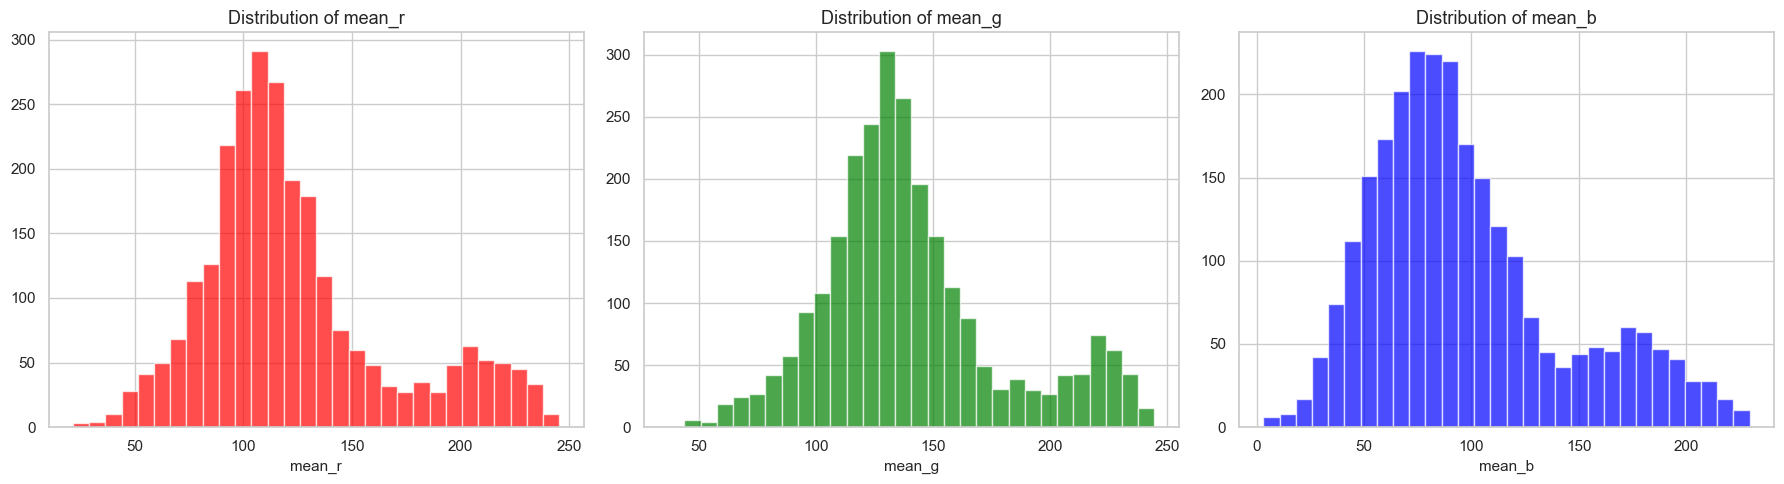

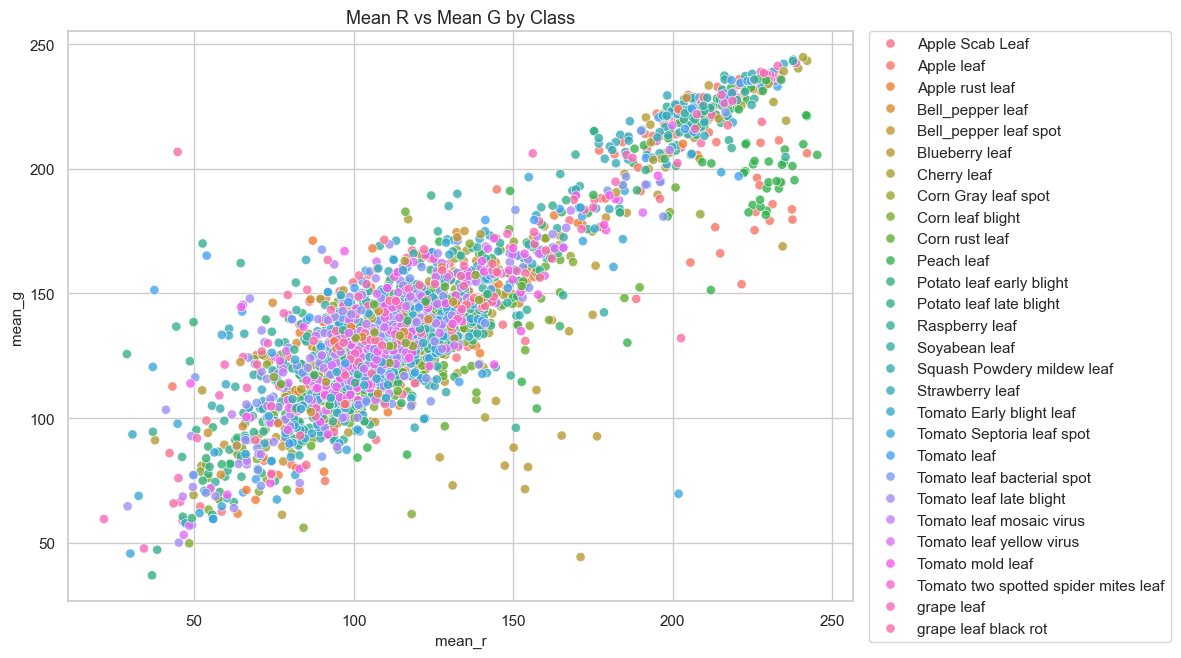

Correlation matrix:


,mean_r,mean_g,mean_b,std_r,std_g,std_b
mean_r,1.000000,0.882480,0.823293,0.280751,0.002976,0.668221
mean_g,0.882480,1.000000,0.840585,0.211504,-0.106165,0.665460
mean_b,0.823293,0.840585,1.000000,0.233954,-0.041113,0.725656
std_r,0.280751,0.211504,0.233954,1.000000,0.642515,0.603406
std_g,0.002976,-0.106165,-0.041113,0.642515,1.000000,0.340943
std_b,0.668221,0.665460,0.725656,0.603406,0.340943,1.000000


Top 5 classes by image count:


,image_count
class_name,
Corn leaf blight,191
Tomato Septoria leaf spot,151
Squash Powdery mildew leaf,130
Raspberry leaf,119
Corn rust leaf,116


Bottom 5 classes by image count:


,image_count
class_name,
Tomato leaf,63
Bell_pepper leaf,61
Cherry leaf,57
Tomato leaf mosaic virus,54
Tomato two spotted spider mites leaf,2


Class imbalance ratio (max/min): 95.50


In [2]:
features_df = ensure_features().copy()

full_stats = features_df.describe(include='all')
class_counts = features_df['class_name'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

print('Full statistical summary:')
display(full_stats)

print('\nClass distribution:')
display(class_counts.to_frame(name='image_count'))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature, color in zip(axes, ['mean_r', 'mean_g', 'mean_b'], ['red', 'green', 'blue']):
    ax.hist(features_df[feature], bins=30, color=color, alpha=0.7)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.scatterplot(data=features_df, x='mean_r', y='mean_g', hue='class_name', s=45, alpha=0.8)
plt.title('Mean R vs Mean G by Class')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

corr_matrix = features_df[['mean_r', 'mean_g', 'mean_b', 'std_r', 'std_g', 'std_b']].corr()
print('Correlation matrix:')
display(corr_matrix)

print('Top 5 classes by image count:')
display(class_counts.head(5).to_frame(name='image_count'))
print('Bottom 5 classes by image count:')
display(class_counts.tail(5).to_frame(name='image_count'))
print(f'Class imbalance ratio (max/min): {imbalance_ratio:.2f}')

## Results & Evaluation

In [3]:
print('EDA completed successfully on the RGB feature dataset.')
print(f'Total rows analyzed: {len(features_df):,}')
print(f'Total classes analyzed: {features_df["class_name"].nunique()}')

EDA completed successfully on the RGB feature dataset.
Total rows analyzed: 2,572
Total classes analyzed: 28


## Conclusion

The EDA step summarizes the RGB feature space, highlights class distribution differences, and reveals how feature pairs relate across disease categories. These insights guide model selection and make later evaluation easier to interpret.